wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Using: model-uomqic9a:v4 score=7.254647254943848


wandb:   1 of 1 files downloaded.  
/tmp/ipykernel_2044132/358938598.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_file, map_location='cp

Mean forward utilization per branch:
  Branch  0: 0.9789
  Branch  1: 0.5076
  Branch  2: 0.3115
  Branch  3: 0.5371
  Branch  4: 0.5412
  Branch  5: 0.4177
  Branch  6: 0.4428
  Branch  7: 0.1265
  Branch  8: 0.2551
  Branch  9: 0.1973
  Branch 10: 0.1909
  Branch 11: 0.2856
  Branch 12: 0.0848
  Branch 13: 0.1018
  Branch 14: 0.3911
  Branch 15: 0.0630
  Branch 16: 0.2790
  Branch 17: 0.6406
  Branch 18: 0.2610
  Branch 19: 0.0844
  Branch 20: 0.1019
  Branch 21: 0.2031
  Branch 22: 0.0942
  Branch 23: 0.2400
  Branch 24: 0.3079
  Branch 25: 0.1906
  Branch 26: 0.5905
  Branch 27: 0.2877
  Branch 28: 0.0979
  Branch 29: 0.1918
  Branch 30: 0.2272
  Branch 31: 0.0792
  Branch 32: 0.1069
  Branch 33: 0.1527
  Branch 34: 0.1701
  Branch 35: 0.2285
  Branch 36: 0.2028
  Branch 37: 0.2340
  Branch 38: 0.1236
  Branch 39: 0.0062
  Branch 40: 0.1139

Mean backward utilization per branch:
  Branch  0: 0.9564
  Branch  1: 0.4896
  Branch  2: 0.3045
  Branch  3: 0.5320
  Branch  4: 0.5220
  Br

  Branch 11: 0.0000
  Branch 12: 0.0000
  Branch 13: 0.0000
  Branch 14: 0.0000
  Branch 15: 0.0000
  Branch 16: 0.0000
  Branch 17: 0.0000
  Branch 18: 0.0000
  Branch 19: 0.0000
  Branch 20: 0.0000
  Branch 21: 0.0000
  Branch 22: 0.0000
  Branch 23: 0.0000
  Branch 24: 0.0000
  Branch 25: 0.0000
  Branch 26: 0.0000
  Branch 27: 0.0000
  Branch 28: 0.0000
  Branch 29: 0.0000
  Branch 30: 0.0000
  Branch 31: 0.0000
  Branch 32: 0.0000
  Branch 33: 0.0000
  Branch 34: 0.0000
  Branch 35: 0.0000
  Branch 36: 0.0000
  Branch 37: 0.0000
  Branch 38: 0.0000
  Branch 39: 0.0000
  Branch 40: 0.0000

Forward Branch Correlations:
  Branch  0: -0.7776
  Branch  1: -0.0499
  Branch  2: -0.1800
  Branch  3: 0.1574
  Branch  4: -0.0704
  Branch  5: -0.7923
  Branch  6: -0.7474
  Branch  7: -0.0007
  Branch  8: 0.5668
  Branch  9: 0.0807
  Branch 10: 0.3809
  Branch 11: -0.6827
  Branch 12: -0.0771
  Branch 13: 0.0670
  Branch 14: -0.3592
  Branch 15: -0.2478
  Branch 16: 0.3779
  Branch 17: 0.0558

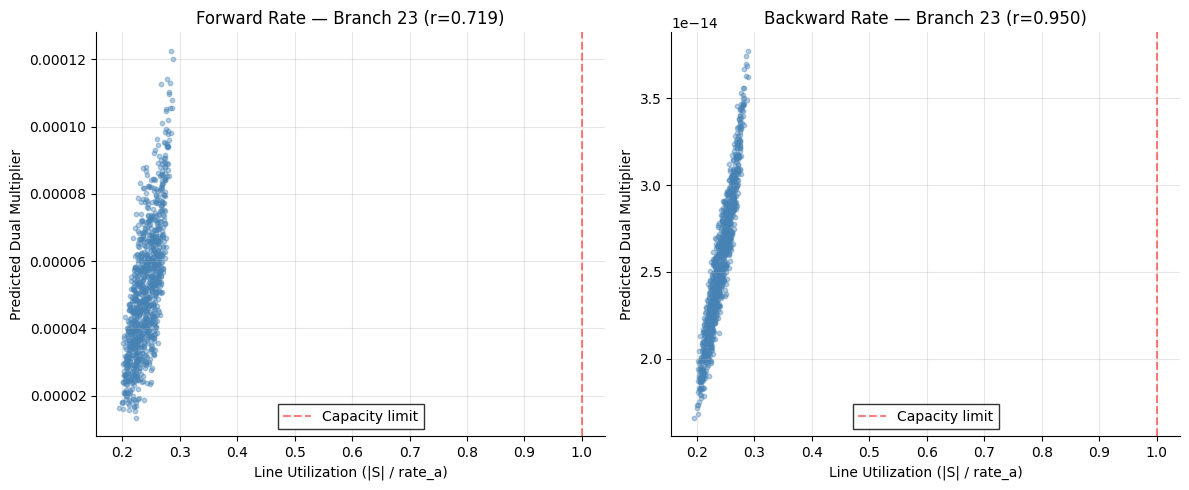

In [1]:
import sys
import os
sys.path.insert(0, '/home/jonathan/opf/src')
os.chdir('/home/jonathan/opf')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from tempfile import TemporaryDirectory
import wandb
from scipy.stats import pearsonr

from opf.test import load_run, data_to_device
from opf.powerflow import BranchParameters

# ── config ────────────────────────────────────────────────────────────────────
RUN_ID = "uomqic9a"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── find best checkpoint via wandb ───────────────────────────────────────────
api = wandb.Api()
run = api.run(f"alelab/opf_param/{RUN_ID}")
artifacts = list(run.logged_artifacts())
model_artifacts = [a for a in artifacts if a.type == "model"]
best_artifact = min(model_artifacts, key=lambda a: a.metadata.get("score", float("inf")))
print(f"Using: {best_artifact.name} score={best_artifact.metadata.get('score')}")

with TemporaryDirectory() as tmpdir:
    checkpoint_path = best_artifact.download(root=tmpdir)
    ckpt_file = str(Path(checkpoint_path) / "model.ckpt")

    dm, opfdual = load_run(
        RUN_ID,
        batch_size=500,
        data_dir="data",
        best=True,
        local_checkpoint_path=ckpt_file,
    )

    # load dual head weights explicitly
    checkpoint = torch.load(ckpt_file, map_location='cpu')
    dual_state = {
        k.replace("model_dual.", ""): v
        for k, v in checkpoint["state_dict"].items()
        if k.startswith("model_dual.")
    }
    opfdual.model_dual.load_state_dict(dual_state, strict=False)

    opfdual = opfdual.to(DEVICE)
    opfdual.eval()

    # ── run inference ─────────────────────────────────────────────────────────
    all_sf_abs = []
    all_st_abs = []
    all_fwd_mult = []
    all_bwd_mult = []
    all_rate_a = []

    with torch.no_grad():
        for data in tqdm(dm.test_dataloader()):
            data = data_to_device(data, DEVICE)
            graph = data.graph
            variables, _, _ = opfdual(data)
            multipliers = opfdual.model_dual.get_multipliers(data)

            num_graphs = graph.num_graphs
            n_branch = graph["branch"].params.shape[0] // num_graphs

            sf_abs = variables.Sf.abs().reshape(num_graphs, n_branch)
            st_abs = variables.St.abs().reshape(num_graphs, n_branch)

            fwd = multipliers["inequality/forward_rate"].reshape(num_graphs, n_branch, 2)
            bwd = multipliers["inequality/backward_rate"].reshape(num_graphs, n_branch, 2)

            branch_params = BranchParameters.from_tensor(graph["branch"]["params"])
            rate_a = branch_params.rate_a.reshape(num_graphs, n_branch)

            all_sf_abs.append(sf_abs.cpu().numpy())
            all_st_abs.append(st_abs.cpu().numpy())
            all_fwd_mult.append(fwd.cpu().numpy())
            all_bwd_mult.append(bwd.cpu().numpy())
            all_rate_a.append(rate_a.cpu().numpy())

# stack
sf_abs   = np.concatenate(all_sf_abs,   axis=0)
st_abs   = np.concatenate(all_st_abs,   axis=0)
fwd_mult = np.concatenate(all_fwd_mult, axis=0)
bwd_mult = np.concatenate(all_bwd_mult, axis=0)
rate_a   = np.concatenate(all_rate_a,   axis=0)

sf_util = sf_abs / (rate_a + 1e-8)
st_util = st_abs / (rate_a + 1e-8)

fwd_upper = fwd_mult[:, :, 1]
bwd_upper = bwd_mult[:, :, 1]

# ── mean utilization ──────────────────────────────────────────────────────────
mean_sf_util = sf_util.mean(axis=0)
mean_st_util = st_util.mean(axis=0)

print("Mean forward utilization per branch:")
for b, u in enumerate(mean_sf_util):
    print(f"  Branch {b:2d}: {u:.4f}", flush=True)

print("\nMean backward utilization per branch:")
for b, u in enumerate(mean_st_util):
    print(f"  Branch {b:2d}: {u:.4f}", flush=True)

top5_fwd = np.argsort(mean_sf_util)[::-1][:5]
top5_bwd = np.argsort(mean_st_util)[::-1][:5]
print(f"\nTop 5 most utilized forward branches: {top5_fwd} with utilization {mean_sf_util[top5_fwd]}")
print(f"Top 5 most utilized backward branches: {top5_bwd} with utilization {mean_st_util[top5_bwd]}")

# ── mean duals ────────────────────────────────────────────────────────────────
mean_fwd_dual = fwd_upper.mean(axis=0)
mean_bwd_dual = bwd_upper.mean(axis=0)

print("\nMean forward dual per branch:")
for b, d in enumerate(mean_fwd_dual):
    print(f"  Branch {b:2d}: {d:.4f}", flush=True)

print("\nMean backward dual per branch:")
for b, d in enumerate(mean_bwd_dual):
    print(f"  Branch {b:2d}: {d:.4f}", flush=True)

# ── per-branch correlation ────────────────────────────────────────────────────
n_branch = sf_abs.shape[1]
fwd_corr = np.zeros(n_branch)
bwd_corr = np.zeros(n_branch)

for b in range(n_branch):
    fwd_corr[b], _ = pearsonr(sf_util[:, b], fwd_upper[:, b])
    bwd_corr[b], _ = pearsonr(st_util[:, b], bwd_upper[:, b])

print("\nForward Branch Correlations:")
for b, c in enumerate(fwd_corr):
    print(f"  Branch {b:2d}: {c:.4f}", flush=True)

print("\nBackward Branch Correlations:")
for b, c in enumerate(bwd_corr):
    print(f"  Branch {b:2d}: {c:.4f}", flush=True)

best_fwd = np.argmax(fwd_corr)
best_bwd = np.argmax(bwd_corr)
print(f"\nBest forward branch: {best_fwd} (r={fwd_corr[best_fwd]:.4f})")
print(f"Best backward branch: {best_bwd} (r={bwd_corr[best_bwd]:.4f})")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, branch, util, mult, corr, label in [
    (axes[0], best_fwd, sf_util, fwd_upper, fwd_corr, "Forward"),
    (axes[1], best_bwd, st_util, bwd_upper, bwd_corr, "Backward"),
]:
    x = util[:, branch]
    y = mult[:, branch]
    ax.scatter(x, y, alpha=0.4, s=10, color='steelblue')
    ax.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Capacity limit')
    ax.set_xlabel('Line Utilization (|S| / rate_a)')
    ax.set_ylabel('Predicted Dual Multiplier')
    ax.set_title(f'{label} Rate — Branch {branch} (r={corr[branch]:.3f})')
    ax.legend(fancybox=False, edgecolor='black')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('dual_vs_utilization.pdf', bbox_inches='tight', dpi=300)
plt.show()

wandb:   1 of 1 files downloaded.  
/tmp/ipykernel_2044132/1822060166.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint2 = torch.load(ckpt_file, map_location='

Mean voltage magnitude and duals per bus:
 Bus   Mean |V|   Dist to bound   Lower dual   Upper dual
   0   1.0555     0.0045          0.0000        0.3287
   1   1.0317     0.0283          0.0000        0.0003
   2   1.0139     0.0461          0.0000        0.0008
   3   1.0039     0.0561          0.0000        0.0004
   4   0.9949     0.0549          0.0000        0.0001
   5   1.0013     0.0587          0.0000        0.0000
   6   0.9910     0.0510          0.0000        0.0000
   7   1.0014     0.0586          0.0000        0.0000
   8   1.0393     0.0207          0.0000        0.0000
   9   1.0357     0.0243          0.0000        0.0001
  10   1.0634     -0.0034          0.0000        0.0001
  11   1.0514     0.0086          0.0000        0.0006
  12   1.0690     -0.0090          0.0000        0.0006
  13   1.0362     0.0238          0.0000        0.0000
  14   1.0314     0.0286          0.0000        0.0000
  15   1.0373     0.0227          0.0000        0.0002
  16   1.0313     


Best lower bound bus: 0 (r=0.0000)
Best upper bound bus: 29 (r=0.9983)


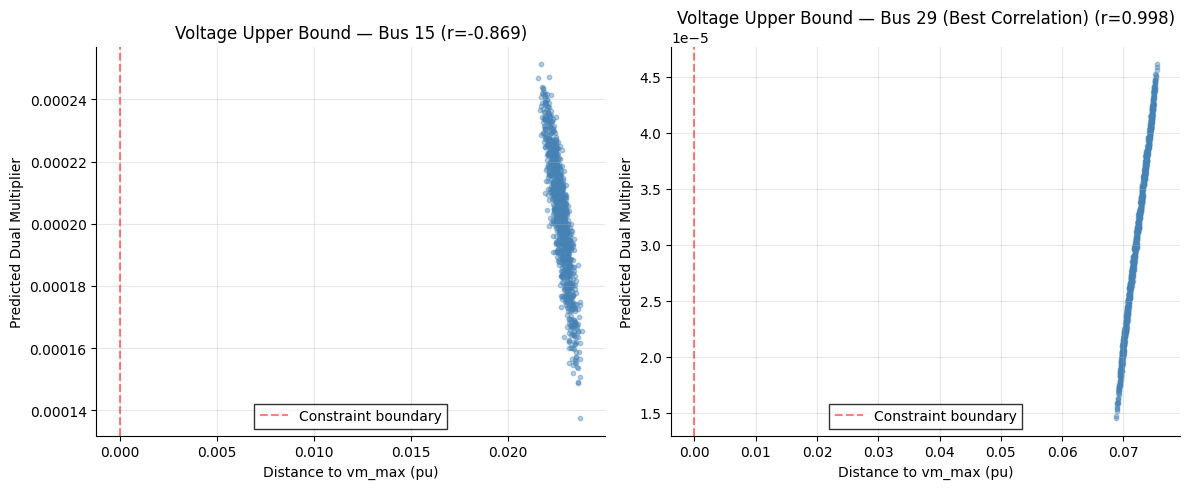

'*****Also try to predict duals on the train dataset, compare relationship in train and relationship in test******'

In [2]:
# ── voltage magnitude analysis ────────────────────────────────────────────────

from opf.powerflow import BusParameters

all_vm = []           # voltage magnitude per bus per sample
all_vm_min = []       # lower voltage bound per bus
all_vm_max = []       # upper voltage bound per bus
all_vm_lower_mult = []  # lower bound multiplier per bus
all_vm_upper_mult = []  # upper bound multiplier per bus

with TemporaryDirectory() as tmpdir:
    checkpoint_path = best_artifact.download(root=tmpdir)
    ckpt_file = str(Path(checkpoint_path) / "model.ckpt")

    dm2, opfdual2 = load_run(
        RUN_ID,
        batch_size=500,
        data_dir="data",
        best=True,
        local_checkpoint_path=ckpt_file,
    )

    checkpoint2 = torch.load(ckpt_file, map_location='cpu')
    dual_state2 = {
        k.replace("model_dual.", ""): v
        for k, v in checkpoint2["state_dict"].items()
        if k.startswith("model_dual.")
    }
    opfdual2.model_dual.load_state_dict(dual_state2, strict=False)
    opfdual2 = opfdual2.to(DEVICE)
    opfdual2.eval()

    with torch.no_grad():
        for data in tqdm(dm2.test_dataloader()):
            data = data_to_device(data, DEVICE)
            graph = data.graph
            variables, _, _ = opfdual2(data)
            multipliers = opfdual2.model_dual.get_multipliers(data)

            num_graphs = graph.num_graphs
            n_bus = graph["bus"].params.shape[0] // num_graphs

            # voltage magnitude per bus
            vm = variables.V.abs().reshape(num_graphs, n_bus)

            # voltage bounds from bus params
            bus_params = BusParameters.from_tensor(graph["bus"]["params"])
            vm_min = bus_params.vm_min.reshape(num_graphs, n_bus)
            vm_max = bus_params.vm_max.reshape(num_graphs, n_bus)

            # voltage magnitude multipliers: (batch*n_bus, 2) → (batch, n_bus, 2)
            vm_mult = multipliers["inequality/voltage_magnitude"].reshape(num_graphs, n_bus, 2)

            all_vm.append(vm.cpu().numpy())
            all_vm_min.append(vm_min.cpu().numpy())
            all_vm_max.append(vm_max.cpu().numpy())
            all_vm_lower_mult.append(vm_mult[:, :, 0].cpu().numpy())
            all_vm_upper_mult.append(vm_mult[:, :, 1].cpu().numpy())

# stack
vm          = np.concatenate(all_vm,           axis=0)  # (1000, 30)
vm_min      = np.concatenate(all_vm_min,       axis=0)
vm_max      = np.concatenate(all_vm_max,       axis=0)
vm_lower    = np.concatenate(all_vm_lower_mult, axis=0)
vm_upper    = np.concatenate(all_vm_upper_mult, axis=0)

# distance from bounds (positive = slack, negative = violated)
dist_lower = vm - vm_min  # how far above lower bound
dist_upper = vm_max - vm  # how far below upper bound
min_dist   = np.minimum(dist_lower, dist_upper)  # distance to nearest bound

# ── mean voltage and duals per bus ────────────────────────────────────────────
mean_vm         = vm.mean(axis=0)
mean_vm_lower   = vm_lower.mean(axis=0)
mean_vm_upper   = vm_upper.mean(axis=0)
mean_min_dist   = min_dist.mean(axis=0)

print("Mean voltage magnitude and duals per bus:")
print(f"{'Bus':>4} {'Mean |V|':>10} {'Dist to bound':>15} {'Lower dual':>12} {'Upper dual':>12}")
for b in range(len(mean_vm)):
    print(f"  {b:2d}   {mean_vm[b]:.4f}     {mean_min_dist[b]:.4f}          {mean_vm_lower[b]:.4f}        {mean_vm_upper[b]:.4f}")

# ── correlation: distance to bound vs dual ────────────────────────────────────
lower_corr = np.zeros(vm.shape[1])
upper_corr = np.zeros(vm.shape[1])

for b in range(vm.shape[1]):
    if vm_lower[:, b].std() > 1e-6:
        lower_corr[b], _ = pearsonr(dist_lower[:, b], vm_lower[:, b])
    if vm_upper[:, b].std() > 1e-6:
        upper_corr[b], _ = pearsonr(dist_upper[:, b], vm_upper[:, b])

print("\nCorrelation (distance to lower bound vs lower dual):")
for b, c in enumerate(lower_corr):
    print(f"  Bus {b:2d}: {c:.4f}", flush=True)

print("\nCorrelation (distance to upper bound vs upper dual):")
for b, c in enumerate(upper_corr):
    print(f"  Bus {b:2d}: {c:.4f}", flush=True)

best_lower_bus = np.argmax(np.abs(lower_corr))
best_upper_bus = np.argmax(np.abs(upper_corr))
print(f"\nBest lower bound bus: {best_lower_bus} (r={lower_corr[best_lower_bus]:.4f})")
print(f"Best upper bound bus: {best_upper_bus} (r={upper_corr[best_upper_bus]:.4f})")

# ── plot: distance to bound vs dual ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, bus, dist, dual, corr, label in [
    (axes[0], 15, dist_upper, vm_upper, upper_corr, "Bus 15"),
    (axes[1], best_upper_bus, dist_upper, vm_upper, upper_corr, f"Bus {best_upper_bus} (Best Correlation)"),
]:
    x = dist[:, bus]
    y = dual[:, bus]
    ax.scatter(x, y, alpha=0.4, s=10, color='steelblue')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Constraint boundary')
    ax.set_xlabel('Distance to vm_max (pu)')
    ax.set_ylabel('Predicted Dual Multiplier')
    ax.set_title(f'Voltage Upper Bound — {label} (r={upper_corr[bus]:.3f})')
    ax.legend(fancybox=False, edgecolor='black')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('voltage_dual_vs_distance.pdf', bbox_inches='tight', dpi=300)
plt.show()

"""Take mean violation per constraint, take mean dual variable over all samples per that constraint, and then plot that for all 420 constraints"""
""" Check STD of constraint level and look at the constraints with the highest STD, maybe normalize STD (different constraints have different magnitude levels)"""
"""Then perhaps work with the ones with the highest STD (the constraints most sensitive to the change in demand for samples)"""
"""Work with constraints that are closest to the constraint boundary, perhaps these will be more meaningful"""
"""Plot lambdas on log scale"""

"""Choose some set of constraint level for all (or some) of the constraints, see dual variable predicted for constraints at that level, and then try backprop to generate sample demand with those levels using some loss function (perhaps mse with desired duals)"""
"""*****Also try to predict duals on the train dataset, compare relationship in train and relationship in test******"""


wandb:   1 of 1 files downloaded.  
/tmp/ipykernel_2044132/2866220239.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint3 = torch.load(ckpt_file, map_location='

Total individual constraints: 338


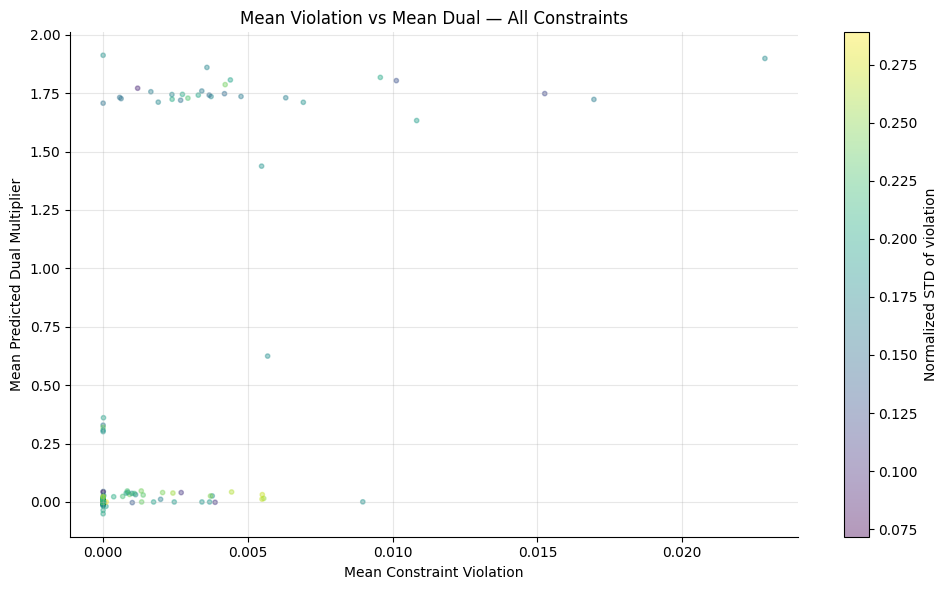


Top 20 most variable constraints (normalized STD):
  inequality/backward_rate/node38/b1                  norm_std=0.2888  mean_viol=0.0000  mean_dual=0.0000
  inequality/backward_rate/node38/b0                  norm_std=0.2888  mean_viol=0.0000  mean_dual=0.0000
  inequality/forward_rate/node38/b1                   norm_std=0.2888  mean_viol=0.0000  mean_dual=0.0001
  inequality/forward_rate/node38/b0                   norm_std=0.2888  mean_viol=0.0000  mean_dual=0.0000
  inequality/reactive_power/node3/b1                  norm_std=0.2877  mean_viol=0.0001  mean_dual=0.0000
  inequality/reactive_power/node3/b0                  norm_std=0.2877  mean_viol=0.0000  mean_dual=0.0000
  inequality/backward_rate/node9/b1                   norm_std=0.2747  mean_viol=0.0000  mean_dual=0.0000
  inequality/backward_rate/node9/b0                   norm_std=0.2747  mean_viol=0.0000  mean_dual=0.0000
  inequality/forward_rate/node9/b1                    norm_std=0.2736  mean_viol=0.0000  mean_dual=0

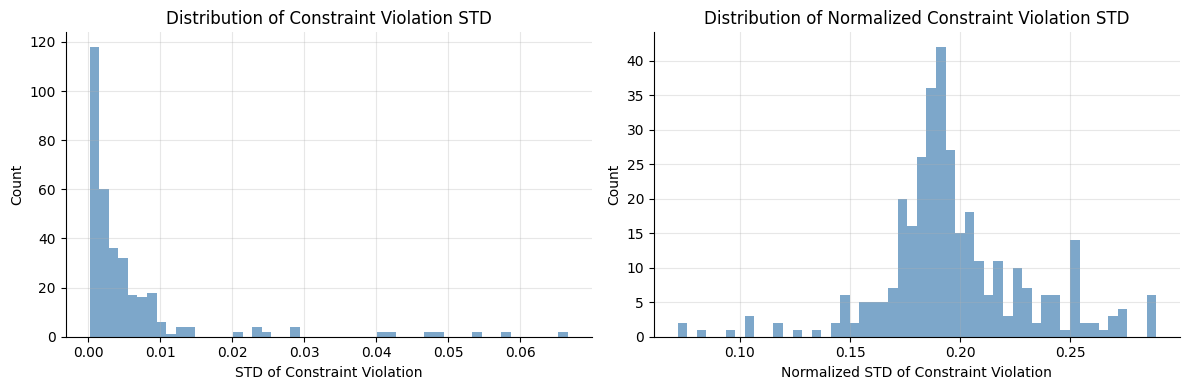

In [3]:
"""
Analysis of all 420 constraints:
1. Mean violation vs mean dual per constraint
2. STD of violations (normalized) to find most variable constraints
3. Focus on constraints closest to boundary
"""

from opf.powerflow import BusParameters, BranchParameters, GenParameters
import opf.powerflow as pf

all_violations = {}   # constraint_name -> list of (n_nodes, n_bound) arrays
all_duals = {}        # constraint_name -> list of (n_nodes, n_bound) arrays

with TemporaryDirectory() as tmpdir:
    checkpoint_path = best_artifact.download(root=tmpdir)
    ckpt_file = str(Path(checkpoint_path) / "model.ckpt")

    dm3, opfdual3 = load_run(
        RUN_ID, batch_size=500, data_dir="data", best=True,
        local_checkpoint_path=ckpt_file,
    )
    checkpoint3 = torch.load(ckpt_file, map_location='cpu')
    dual_state3 = {
        k.replace("model_dual.", ""): v
        for k, v in checkpoint3["state_dict"].items()
        if k.startswith("model_dual.")
    }
    opfdual3.model_dual.load_state_dict(dual_state3, strict=False)
    opfdual3 = opfdual3.to(DEVICE)
    opfdual3.eval()

    with torch.no_grad():
        for data in tqdm(dm3.test_dataloader()):
            data = data_to_device(data, DEVICE)
            graph = data.graph
            variables, _, _ = opfdual3(data)
            multipliers = opfdual3.model_dual.get_multipliers(data)
            num_graphs = graph.num_graphs

            # get raw violations per constraint type
            violations = opfdual3.get_constraint_violations(variables, graph)

            for name, v in violations.items():
                n_nodes = v.shape[0] // num_graphs
                n_bounds = v.shape[1] if len(v.shape) > 1 else 1
                v_reshaped = v.reshape(num_graphs, n_nodes, -1).cpu().numpy()
                if name not in all_violations:
                    all_violations[name] = []
                all_violations[name].append(v_reshaped)

            for name, m in multipliers.items():
                n_nodes = m.shape[0] // num_graphs
                m_reshaped = m.reshape(num_graphs, n_nodes, -1).cpu().numpy()
                if name not in all_duals:
                    all_duals[name] = []
                all_duals[name].append(m_reshaped)

# stack across batches → (n_samples, n_nodes, n_bounds)
violations_stacked = {k: np.concatenate(v, axis=0) for k, v in all_violations.items()}
duals_stacked = {k: np.concatenate(v, axis=0) for k, v in all_duals.items()}

# ── flatten to individual constraints ─────────────────────────────────────────
# each entry: one scalar per (sample, node, bound)
constraint_names = []
mean_violations = []
mean_duals = []
std_violations = []
norm_std_violations = []

for name in duals_stacked:
    if name not in violations_stacked:
        continue
    v = violations_stacked[name]  # (n_samples, n_nodes, n_bounds)
    d = duals_stacked[name]

    n_nodes = v.shape[1]
    n_bounds = v.shape[2]

    for node in range(n_nodes):
        for bound in range(n_bounds):
            v_series = v[:, node, bound]   # (n_samples,)
            d_series = d[:, node, bound]

            # violation: only positive values matter (actual violations)
            viol_positive = np.maximum(v_series, 0)

            mean_v = viol_positive.mean()
            mean_d = d_series.mean()
            std_v  = v_series.std()
            # normalized STD: std / (mean range of constraint values)
            v_range = v_series.max() - v_series.min()
            norm_std = std_v / (v_range + 1e-8)

            constraint_names.append(f"{name}/node{node}/b{bound}")
            mean_violations.append(mean_v)
            mean_duals.append(mean_d)
            std_violations.append(std_v)
            norm_std_violations.append(norm_std)

mean_violations  = np.array(mean_violations)
mean_duals       = np.array(mean_duals)
std_violations   = np.array(std_violations)
norm_std_violations = np.array(norm_std_violations)

print(f"Total individual constraints: {len(constraint_names)}")

# ── Plot 1: mean violation vs mean dual (all 420 constraints) ─────────────────
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(mean_violations, mean_duals, alpha=0.4, s=10,
                     c=norm_std_violations, cmap='viridis')
plt.colorbar(scatter, ax=ax, label='Normalized STD of violation')
ax.set_xlabel('Mean Constraint Violation')
ax.set_ylabel('Mean Predicted Dual Multiplier')
ax.set_title('Mean Violation vs Mean Dual — All Constraints')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('all_constraints_mean_viol_vs_dual.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── Plot 2: top 20 constraints by normalized STD ──────────────────────────────
top20_idx = np.argsort(norm_std_violations)[::-1][:20]
print("\nTop 20 most variable constraints (normalized STD):")
for i in top20_idx:
    print(f"  {constraint_names[i]:50s}  norm_std={norm_std_violations[i]:.4f}  "
          f"mean_viol={mean_violations[i]:.4f}  mean_dual={mean_duals[i]:.4f}")

# ── Plot 3: constraints closest to boundary (small mean distance) ──────────────
# "closest to boundary" = smallest mean |violation| that is still sometimes positive
active_mask = mean_violations > 1e-6  # occasionally violated
closest_idx = np.argsort(mean_violations[active_mask])[:20]
active_indices = np.where(active_mask)[0][closest_idx]

print("\nTop 20 constraints closest to boundary (occasionally violated, low mean):")
for i in active_indices:
    print(f"  {constraint_names[i]:50s}  mean_viol={mean_violations[i]:.6f}  "
          f"std={std_violations[i]:.4f}  mean_dual={mean_duals[i]:.4f}")

# ── Plot 4: STD distribution across all constraints ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(std_violations, bins=50, color='steelblue', alpha=0.7)
axes[0].set_xlabel('STD of Constraint Violation')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Constraint Violation STD')
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(norm_std_violations, bins=50, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Normalized STD of Constraint Violation')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Normalized Constraint Violation STD')
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('constraint_std_distribution.pdf', bbox_inches='tight', dpi=300)
plt.show()

wandb:   1 of 1 files downloaded.  
/tmp/ipykernel_2044132/3822072103.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_g = torch.load(ckpt_file, map_location=


Running inference on train set...


train: 100%|██████████| 16/16 [00:02<00:00,  7.64it/s]



Running inference on test set...


test: 100%|██████████| 2/2 [00:00<00:00,  8.35it/s]


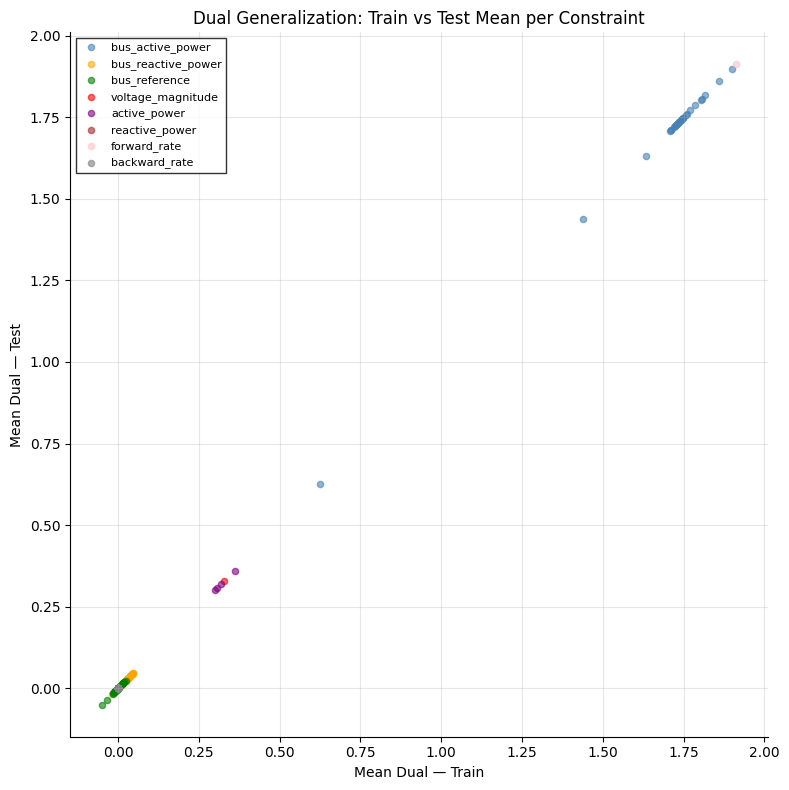


Mean absolute difference (train vs test): 0.000013
Max absolute difference: 0.000618

Top 10 constraints with largest train/test gap:
  equality/bus_active_power/node2/b0                       train=1.4382  test=1.4376  diff=0.0006
  equality/bus_active_power/node0/b0                       train=0.6250  test=0.6245  diff=0.0005
  equality/bus_active_power/node1/b0                       train=1.8605  test=1.8601  diff=0.0004
  inequality/voltage_magnitude/node0/b1                    train=0.3284  test=0.3287  diff=0.0003
  equality/bus_active_power/node6/b0                       train=1.8040  test=1.8037  diff=0.0003
  inequality/active_power/node2/b1                         train=0.3609  test=0.3607  diff=0.0002
  equality/bus_active_power/node7/b0                       train=1.7479  test=1.7482  diff=0.0002
  inequality/active_power/node3/b1                         train=0.3197  test=0.3198  diff=0.0001
  inequality/active_power/node5/b1                         train=0.3012  test=0.3

In [4]:
"""
Train vs Test: mean dual values per constraint, scatter plot
"""

dual_means = {}

with TemporaryDirectory() as tmpdir:
    checkpoint_path = best_artifact.download(root=tmpdir)
    ckpt_file = str(Path(checkpoint_path) / "model.ckpt")

    dm_g, opfdual_g = load_run(
        RUN_ID, batch_size=500, data_dir="data", best=True,
        local_checkpoint_path=ckpt_file,
    )
    checkpoint_g = torch.load(ckpt_file, map_location='cpu')
    dual_state_g = {
        k.replace("model_dual.", ""): v
        for k, v in checkpoint_g["state_dict"].items()
        if k.startswith("model_dual.")
    }
    opfdual_g.model_dual.load_state_dict(dual_state_g, strict=False)
    opfdual_g = opfdual_g.to(DEVICE)
    opfdual_g.eval()

    for split, loader in [("train", dm_g.train_dataloader()), ("test", dm_g.test_dataloader())]:
        print(f"\nRunning inference on {split} set...")

        split_duals = {}  # constraint_name -> list of (n_samples, n_nodes, n_bounds)

        with torch.no_grad():
            for data in tqdm(loader, desc=split):
                data = data_to_device(data, DEVICE)
                graph = data.graph
                variables, _, _ = opfdual_g(data)
                multipliers = opfdual_g.model_dual.get_multipliers(data)

                num_graphs = graph.num_graphs

                for name, m in multipliers.items():
                    n_nodes = m.shape[0] // num_graphs
                    m_reshaped = m.reshape(num_graphs, n_nodes, -1).cpu().numpy()
                    if name not in split_duals:
                        split_duals[name] = []
                    split_duals[name].append(m_reshaped)

        # stack and compute mean per constraint per node per bound
        dual_means[split] = {}
        for name, arrays in split_duals.items():
            stacked = np.concatenate(arrays, axis=0)  # (n_samples, n_nodes, n_bounds)
            dual_means[split][name] = stacked.mean(axis=0)  # (n_nodes, n_bounds)

# ── flatten to individual constraints ─────────────────────────────────────────
constraint_labels = []
train_means = []
test_means = []
constraint_types = []

type_colors = {
    'equality/bus_active_power': 'steelblue',
    'equality/bus_reactive_power': 'orange',
    'equality/bus_reference': 'green',
    'inequality/voltage_magnitude': 'red',
    'inequality/active_power': 'purple',
    'inequality/reactive_power': 'brown',
    'inequality/forward_rate': 'pink',
    'inequality/backward_rate': 'gray',
}

for name in dual_means['train']:
    if name not in dual_means['test']:
        continue
    train_arr = dual_means['train'][name]   # (n_nodes, n_bounds)
    test_arr  = dual_means['test'][name]

    n_nodes, n_bounds = train_arr.shape
    for node in range(n_nodes):
        for bound in range(n_bounds):
            constraint_labels.append(f"{name}/node{node}/b{bound}")
            train_means.append(train_arr[node, bound])
            test_means.append(test_arr[node, bound])
            constraint_types.append(name)

train_means = np.array(train_means)
test_means  = np.array(test_means)

# ── scatter plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))

for ctype, color in type_colors.items():
    mask = np.array(constraint_types) == ctype
    if mask.sum() == 0:
        continue
    ax.scatter(train_means[mask], test_means[mask],
               color=color, alpha=0.6, s=20, label=ctype.split('/')[-1])

# diagonal line = perfect generalization

ax.set_xlabel('Mean Dual — Train')
ax.set_ylabel('Mean Dual — Test')
ax.set_title('Dual Generalization: Train vs Test Mean per Constraint')
ax.legend(fancybox=False, edgecolor='black', fontsize=8)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('dual_generalization_scatter.pdf', bbox_inches='tight', dpi=300)
plt.show()

# ── print summary ──────────────────────────────────────────────────────────────
diff = np.abs(train_means - test_means)
print(f"\nMean absolute difference (train vs test): {diff.mean():.6f}")
print(f"Max absolute difference: {diff.max():.6f}")
print(f"\nTop 10 constraints with largest train/test gap:")
top10 = np.argsort(diff)[::-1][:10]
for i in top10:
    print(f"  {constraint_labels[i]:55s}  train={train_means[i]:.4f}  test={test_means[i]:.4f}  diff={diff[i]:.4f}")

In [5]:
# violation and dual range for all constraints
print(f"{'Constraint':55s} {'viol_min':>10} {'viol_max':>10} {'viol_std':>10} {'dual_mean':>10} {'dual_std':>10}")
print("-" * 110)

for name in duals_stacked:
    if name not in violations_stacked:
        continue
    v = violations_stacked[name]  # (n_samples, n_nodes, n_bounds)
    d = duals_stacked[name]

    n_nodes = v.shape[1]
    n_bounds = v.shape[2]

    for node in range(n_nodes):
        for bound in range(n_bounds):
            v_series = v[:, node, bound]
            d_series = d[:, node, bound]

            print(f"{name}/node{node}/b{bound}:55s "
                  f"{v_series.min():>10.6f} "
                  f"{v_series.max():>10.6f} "
                  f"{v_series.std():>10.6f} "
                  f"{d_series.mean():>10.6f} "
                  f"{d_series.std():>10.6f}")

Constraint                                                viol_min   viol_max   viol_std  dual_mean   dual_std
--------------------------------------------------------------------------------------------------------------
equality/bus_active_power/node0/b0:55s  -0.001355   0.012742   0.002506   0.624484   0.024454
equality/bus_active_power/node1/b0:55s  -0.011022   0.023481   0.005872   1.860116   0.055708
equality/bus_active_power/node2/b0:55s  -0.003818   0.015705   0.003570   1.437568   0.015971
equality/bus_active_power/node3/b0:55s  -0.011292   0.032380   0.008369   1.632813   0.003935
equality/bus_active_power/node4/b0:55s   0.017301   0.028884   0.002022   1.898571   0.028069
equality/bus_active_power/node5/b0:55s   0.011562   0.020769   0.001485   1.723212   0.013390
equality/bus_active_power/node6/b0:55s   0.002312   0.016150   0.001744   1.803682   0.017241
equality/bus_active_power/node7/b0:55s   0.007175   0.019968   0.001516   1.748169   0.014275
equality/bus_active_power/

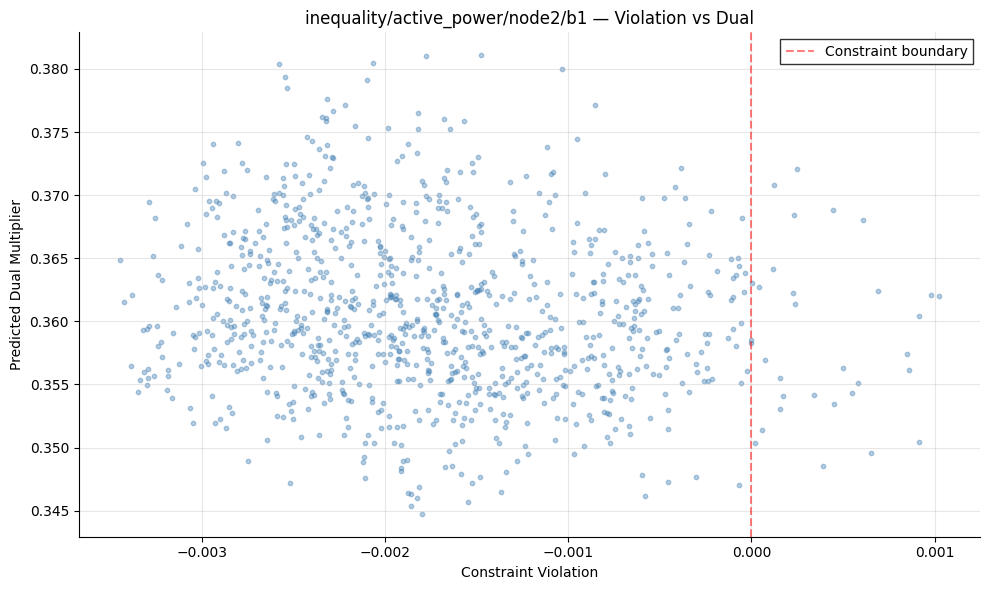

In [7]:
duals = duals_stacked["inequality/active_power"][:, 2, 1]    # (1000,)
violations = violations_stacked["inequality/active_power"][:, 2, 1]  # (1000,)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(violations, duals, alpha=0.4, s=10, color='steelblue')
ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='Constraint boundary')
ax.set_xlabel('Constraint Violation')
ax.set_ylabel('Predicted Dual Multiplier')
ax.set_title('inequality/active_power/node2/b1 — Violation vs Dual')
ax.legend(fancybox=False, edgecolor='black')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()